# 11_数据预处理方法-数据增强

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/lenna.jpg`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 数据增强保留图片变换与训练集增强思想；改用本地图片和传统分类器，移除 CIFAR-10 下载及 CNN 训练。增强是否保持标签语义需要结合具体任务判断。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家聊聊数据预处理方法中的数据增强\~

#### 什么是数据增强？

**数据增强（Data Augmentation）**，简单来说，就是“想办法把已有的数据变多”的一种技术手段。

在机器学习，特别是深度学习中，模型的表现往往和数据的质量与数量密切相关。如果数据不够，模型可能学得不扎实，甚至出现“记死了”的情况。为了缓解这个问题，我们可以通过一些方法“制造”出更多的数据，虽然它们是从原始数据“变”出来的，但依然可以让模型更好地学习。这就是数据增强。

比如，当你在教一个小孩认识“猫”。如果你只给他看一张猫的照片，他可能只记住那一只猫的样子。如果你给他看各种角度、颜色、姿势、光线条件下的猫，他就能真正理解“猫是什么”。这就是数据增强的思路：让模型见识更多“变化”，更全面地学习。

#### 数据增强的作用

1. **增加数据量**：从原有数据中扩展出更多样本。
2. **提高模型泛化能力**：模型能更好地适应未见过的数据。
3. **减少过拟合风险**：防止模型只是“死记硬背”训练数据。

### 常见的数据增强方法

按数据类型分类：

**图像数据增强方法**：

- 水平或垂直翻转
- 旋转、缩放、平移
- 裁剪、加噪声、调整亮度和对比度
- 仿射变换、颜色扰动等

**文本数据增强方法**：

- 同义词替换（如“开心”换成“高兴”）
- 随机插入或删除词语
- 改变句子结构（适用于某些自然语言处理任务）

**音频数据增强方法**：

- 改变语速或音调
- 添加背景噪声
- 剪切、拼接音频段等

再举一个例子：

你要训练一个语音识别系统识别“你好”这个词。如果你只用一个人、一种语调、一种背景来录音，系统学到的知识会很有限。你可以让不同人、在不同场景、用不同语速说“你好”，再把这些音频喂给模型，这样它就能更准确地识别各种“你好”了。这就是数据增强的实际意义。

## 原理详解

### 1. 数学定义

#### 学习任务的基本数学建模

在监督学习中，一个模型试图从数据集中学习一个**映射函数**：


$$
f: \mathcal{X} \rightarrow \mathcal{Y}
$$


其中：

- $\mathcal{X}$：输入空间（如图片、文本、音频等）
- $\mathcal{Y}$：输出空间（如分类标签）

训练集由 $n$ 个样本组成：


$$
\mathcal{D} = \{(x_1, y_1), (x_2, y_2), ..., (x_n, y_n)\} \subset \mathcal{X} \times \mathcal{Y}
$$


学习目标是通过最小化期望风险（Expected Risk）：


$$
R(f) = \mathbb{E}_{(x, y) \sim P(x, y)} [\mathcal{L}(f(x), y)]
$$


由于真实分布 $P(x, y)$ 不可得，使用经验风险（Empirical Risk）替代：


$$
\hat{R}(f) = \frac{1}{n} \sum_{i=1}^{n} \mathcal{L}(f(x_i), y_i)
$$


### 2. 数据增强的引入：数学视角

数据增强的核心思想是：**构造一个增强变换** $T: \mathcal{X} \rightarrow \mathcal{X}$，保持标签不变或遵循一定的变换规则。

对图像分类任务来说，这意味着：


$$
(x, y) \rightarrow (T(x), y)
$$


#### 增广的数据分布

数据增强可以被理解为构造一个新的数据分布 $\tilde{P}(x, y)$，以模拟原始分布 $P(x, y)$ 的变化形式。即：


$$
\tilde{P}(x, y) = \int_{T \in \mathcal{T}} P(T(x), y) \cdot q(T) \, dT
$$


其中：

- $\mathcal{T}$：增强变换的集合（如旋转、裁剪等）
- $q(T)$：对变换的采样分布（通常均匀或高斯）
- $T(x)$：对原始样本 $x$ 应用增强变换后的样本

这体现了一个“局部平滑假设”：在局部区域内数据扰动不应改变其标签。

### 3. 泛化误差分析中的作用

数据增强的根本目的之一是**提升模型的泛化能力**，即降低泛化误差：


$$
\text{Generalization Error} = R(f) - \hat{R}(f)
$$


当数据增强被正确地设计时，它可以：

- 增加样本的**多样性**
- 增强模型对输入空间的小扰动的**鲁棒性**
- 促使模型在决策边界附近学到更平滑的函数

这与以下理论相契合：

### 稳定性理论

如果数据增强能够使学习算法在对输入扰动下输出不发生大的变化（即模型稳定），那么根据学习稳定性理论，泛化误差界将更小。

定义模型对输入扰动的敏感度为：


$$
\Delta = \sup_{T \in \mathcal{T}} \left| \mathcal{L}(f(T(x)), y) - \mathcal{L}(f(x), y) \right|
$$


目标是通过设计变换使得：


$$
\Delta \approx 0
$$


这意味着数据增强促使学习算法具备更高的**局部一致性（local consistency）**。

### 4. 数据增强算法的一般流程

**输入：**

- 原始数据集：$\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n}$
- 增强变换集合：$\mathcal{T} = \{T_1, T_2, ..., T_k\}$
- 增强策略分布：$q(T)$，控制各个变换采样概率
- 增强次数参数：$m$，每个样本生成几次增强样本

**步骤：**

1. 对于每个原始样本 $(x_i, y_i)$，重复以下过程 $m$ 次：


$$
\text{采样 } T \sim q(T)
$$


$$
\text{生成增强样本 } x_i' = T(x_i)
$$


1. 构造增强数据集：


$$
\mathcal{D}' = \mathcal{D} \cup \left\{(x_i', y_i) \mid i = 1, ..., n, \text{ 每个生成 } m \text{ 个增强样本} \right\}
$$


1. 用新的训练集 $\mathcal{D}'$ 来训练模型，通过最小化如下经验风险：


$$
\hat{R}_{aug}(f) = \frac{1}{n(1 + m)} \sum_{i=1}^{n} \left( \mathcal{L}(f(x_i), y_i) + \sum_{j=1}^{m} \mathcal{L}(f(T_j(x_i)), y_i) \right)
$$


### 5. 特定增强策略

#### 图像旋转（旋转角度 $\theta$）

令 $x$ 表示二维图像像素点构成的矩阵，坐标变换为：


$$
T_\theta(x) = R(\theta) \cdot x, \quad \text{其中} \quad R(\theta) = \begin{bmatrix} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{bmatrix}
$$


#### 图像缩放（缩放因子 $s$）


$$
T_s(x) = s \cdot x
$$


#### 加性高斯噪声

对图像 $x$，加入服从 $\mathcal{N}(0, \sigma^2)$ 的高斯噪声：


$$
T_{noise}(x) = x + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)
$$


### 6. 数据增强的理论优化（信息论视角）

在信息论中，可以从最小化互信息的角度来解释数据增强对泛化的帮助。

目标是最小化输入扰动对输出分布的影响：


$$
\min_f I(f(T(x)); y) - I(f(x); y)
$$


即增强后的预测结果和原始预测结果之间互信息的差应尽量小，说明模型对输入变换不敏感。

总结一下上述内容：

| 模块 | 内容 |
|-|-|
| 数学定义 | 构造增强映射 $T: \mathcal{X} \rightarrow \mathcal{X}$，保持或近似保持标签 |
| 分布层面 | 构造变换后的样本分布 $\tilde{P}(x, y)$，模拟数据的真实变化 |
| 泛化提升 | 减少经验风险与期望风险的差距，提高模型稳定性与鲁棒性 |
| 算法流程 | 从原样本生成多个变换样本，合并训练数据，重新训练模型 |
| 理论支撑 | 局部平滑假设、稳定性理论、信息论角度互信息最小化 |

## 完整案例

本例首先使用本地 lenna.jpg 展示水平翻转、旋转与亮度调整。图像变换是否保留标签取决于任务，例如数字翻转可能改变类别，不能机械地应用所有增强。

随后在模拟表格分类数据上演示小幅高斯噪声增强。先划分数据，并只用训练集拟合标准化器；噪声样本只添加到训练集。原始训练集和增强训练集各训练一个逻辑回归模型，在相同的原始测试集上比较准确率。数据增强不保证提高性能。

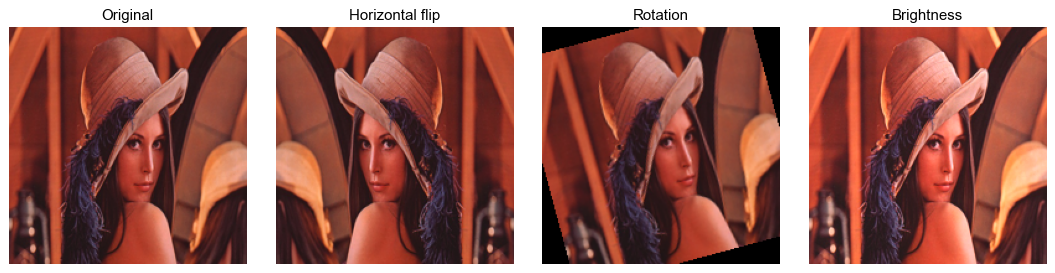

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# 使用本地图片演示几何与颜色增强，不下载 CIFAR-10 或训练神经网络。
original = Image.open(DATA_DIR / 'lenna.jpg').convert('RGB').resize((192, 192))
variants = [original, original.transpose(Image.Transpose.FLIP_LEFT_RIGHT),
            original.rotate(15, resample=Image.Resampling.BILINEAR),
            ImageEnhance.Brightness(original).enhance(1.25)]
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, img, title in zip(axes, variants, ['Original', 'Horizontal flip', 'Rotation', 'Brightness']):
    ax.imshow(img); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

In [3]:
# 一个独立的表格分类实验：先划分，再只对训练集添加小幅噪声。
X, y = make_classification(n_samples=600, n_features=8, n_informative=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test)
rng = np.random.default_rng(42)
X_augmented = np.vstack([X_train, X_train + rng.normal(0, 0.05, X_train.shape)])
y_augmented = np.tile(y_train, 2)

In [4]:
baseline = LogisticRegression(max_iter=1000).fit(X_train, y_train)
augmented = LogisticRegression(max_iter=1000).fit(X_augmented, y_augmented)
print('原始训练集准确率:', accuracy_score(y_test, baseline.predict(X_test)))
print('增强训练集准确率:', accuracy_score(y_test, augmented.predict(X_test)))
print('增强不保证提高性能；噪声尺度应在训练集内部验证。')

原始训练集准确率: 0.8133333333333334
增强训练集准确率: 0.8133333333333334
增强不保证提高性能；噪声尺度应在训练集内部验证。


## 模型分析

### 1.数据增强的优缺点

**优点：**

1. **提升泛化能力，减少过拟合**：原始数据集有限时，模型很容易记住训练样本而不是学习模式。数据增强模拟了更多“虚拟样本”，使模型更健壮、稳定。
2. **无需额外标注成本**：数据增强不需要人工增加数据标签，可以快速扩展训练数据集，降低数据收集成本。
3. **提升模型鲁棒性**：如旋转、裁剪、颜色扰动等增强能训练模型应对真实场景下的图像变化（模糊、遮挡、亮度变化等），提高实际部署时的表现力。
4. **对小样本学习尤为重要**：数据量小的任务中，数据增强几乎是必须手段，用以防止过拟合。
5. **适用于几乎所有图像任务**：数据增强可无缝应用于分类、目标检测、语义分割等任务，是极其通用的预处理方法。

**缺点：**

1. **增强策略依赖经验，难以调优**：手工设计的增强策略往往需要大量实验，参数设置（如旋转角度、颜色扰动幅度）缺乏统一标准。
2. **增强可能引入伪样本风险**：如果增强过度，可能改变了图像原意，比如将“6”旋转成了“9”，引入标签噪声，反而降低性能。
3. **对某些任务效果有限或无效**：如医疗图像分析、精细纹理识别等任务，增强操作可能破坏关键信息。
4. **增加训练时间与计算成本**：增强在每个epoch中动态生成图像，带来额外CPU/GPU负载，尤其是在大规模训练中显著。

### 2.与相似数据增强算法的对比

| 增强策略 | 机制简述 | 是否自动调参 | 增强强度控制 | 引入伪样本风险 | 适用任务 |
|-|-|-|-|-|-|
| **手工增强** | 人工设定旋转、裁剪、翻转、颜色扰动等操作 | 否 | 中 | 有时有 | 通用分类、小样本学习 |
| **AutoAugment** | 搜索最优增强策略组合（RL优化） | 是 | 可调 | 较低 | 高端分类任务、ImageNet等 |
| **RandAugment** | 随机选增强操作 + 增强强度固定 | 是（少调参） | 有（n,m） | 中 | 较推荐通用任务 |
| **TrivialAugment** | 单个随机操作，强度自动 | 是（零调参） | 自适应 | 较低 | 移动端、小模型场景 |
| **MixUp / CutMix** | 图像/标签混合技术，生成混合训练样本 | 是（规则明确） | 强 | 有一定风险 | 分类任务、大模型 |
| **GAN-based合成数据** | 通过生成模型合成新样本 | 是 | 非常强 | 极高 | 特定小样本、数据隐私任务 |

### 3.什么时候优选，什么时候考虑替代算法？

#### 推荐使用本案例中“手工增强”的情况：

- **快速实验验证**：无需搜索算法、调参方便；
- **任务简单、数据少**：手工增强提升足够显著；
- **资源有限场景**：避免AutoAugment等高开销方法；
- **需要人为控制数据多样性**：可精确配置增强组合。

#### 考虑替代增强策略的情况：

- 若需要**更高精度、模型部署在严苛环境（如工业检测）**，建议使用 **AutoAugment 或 RandAugment**，它们能更系统性地提升模型能力；
- 若项目对推理时间和模型体积要求严格（如移动端），可使用 **TrivialAugment**；
- 若对抗样本或鲁棒性要求极高，可结合 **MixUp、CutMix、Adversarial Augmentation**；
- 若样本极少（如医学图像仅数百张），建议引入 **GAN生成样本** 进行数据扩展。

## 最后

在绝大多数图像任务中，“数据增强”是不可或缺的预处理步骤。

数据增强通过对原始训练数据进行多样化变换，提升模型对图像扰动的鲁棒性。它能有效缓解过拟合问题，增强模型的泛化能力。尤其在数据量有限或类别不平衡时，数据增强是提高模型性能的关键手段。